# 06f: Customer Churn Prediction with Support Vector Machine (RBF Kernel)

**RetailPulse AI Platform** • *Dedicated Classification Model*

### Model Scope:
- Ingest leak-free customer behavioral signals.
- Stratified 80/20 train/test holdout.
- Train Support Vector Machine (RBF Kernel).
- Compute full classification stats:
  - **Confusion Matrix** (True Positives, False Positives, True Negatives, False Negatives)
  - **Classification Report** (Precision, Recall, F1 for Active and Churned classes)
  - **AUC-ROC Score**
  - **Precision @ Top 20% Highest Risk**
- Render visual Confusion Matrix heatmap and ROC Curve.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, precision_score

churn_path = os.path.join('..', '..', 'data', 'processed', 'churn_features.csv')
df = pd.read_csv(churn_path)

feature_cols = [
    'total_orders', 'total_quantity', 'avg_quantity_per_line',
    'total_spend', 'avg_order_value', 'unique_products_bought',
    'weekend_purchase_ratio', 'days_as_customer',
    'purchase_frequency_days', 'F_Score', 'M_Score'
]

X = df[feature_cols].copy()
y = df['is_churned'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

if True:
    scaler = StandardScaler()
    X_train_proc = scaler.fit_transform(X_train)
    X_test_proc = scaler.transform(X_test)
else:
    X_train_proc = X_train
    X_test_proc = X_test
    
print(f'Training size: {len(X_train):,}, Test size: {len(X_test):,}')

Training size: 4,702, Test size: 1,176


In [2]:
# Train Support Vector Machine (RBF Kernel)
from sklearn.svm import SVC
model = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
model.fit(X_train_proc, y_train)

y_pred = model.predict(X_test_proc)
y_prob = model.predict_proba(X_test_proc)[:, 1]

# Precision @ Top 20%
top_20_cutoff = int(len(y_test) * 0.20)
top_20_idx = np.argsort(y_prob)[-top_20_cutoff:]
p_top20 = precision_score(y_test[top_20_idx], np.ones(top_20_cutoff))
auc = roc_auc_score(y_test, y_prob)

print('========================================')
print(f'SUPPORT VECTOR MACHINE (RBF KERNEL) CLASSIFIER STATS:')
print('========================================')
print(f'Area Under ROC Curve (AUC-ROC): {auc:.4f} (Target: >= 0.88)')
print(f'Precision @ Top 20% Highest Risk: {p_top20:.4f} (Target: >= 0.75)')
print('========================================\n')
print('CLASSIFICATION REPORT:')
print(classification_report(y_test, y_pred, target_names=['Active (0)', 'Churned (1)']))

C:\Users\kanis\Desktop\internship project\venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


SUPPORT VECTOR MACHINE (RBF KERNEL) CLASSIFIER STATS:
Area Under ROC Curve (AUC-ROC): 0.7987 (Target: >= 0.88)
Precision @ Top 20% Highest Risk: 0.7787 (Target: >= 0.75)

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

  Active (0)       0.79      0.64      0.71       578
 Churned (1)       0.71      0.83      0.76       598

    accuracy                           0.74      1176
   macro avg       0.75      0.74      0.74      1176
weighted avg       0.75      0.74      0.74      1176



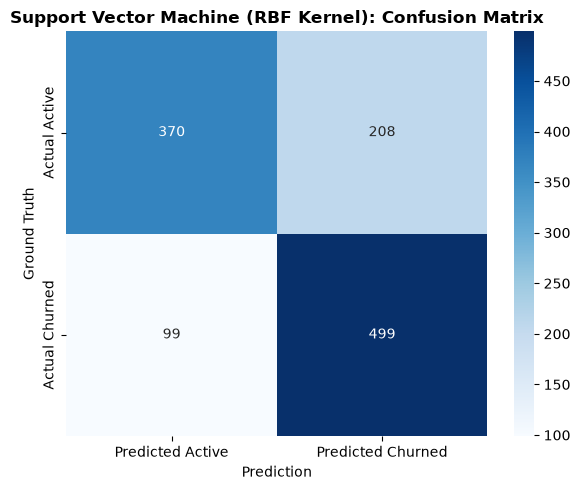

Confusion Matrix Breakdown: True Negatives=370, False Positives=208, False Negatives=99, True Positives=499


In [3]:
# 1. Visual Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted Active', 'Predicted Churned'],
    yticklabels=['Actual Active', 'Actual Churned']
)
plt.title('Support Vector Machine (RBF Kernel): Confusion Matrix', fontsize=12, fontweight='bold')
plt.ylabel('Ground Truth')
plt.xlabel('Prediction')
plt.tight_layout()
plt.show()

print(f'Confusion Matrix Breakdown: True Negatives={tn}, False Positives={fp}, False Negatives={fn}, True Positives={tp}')

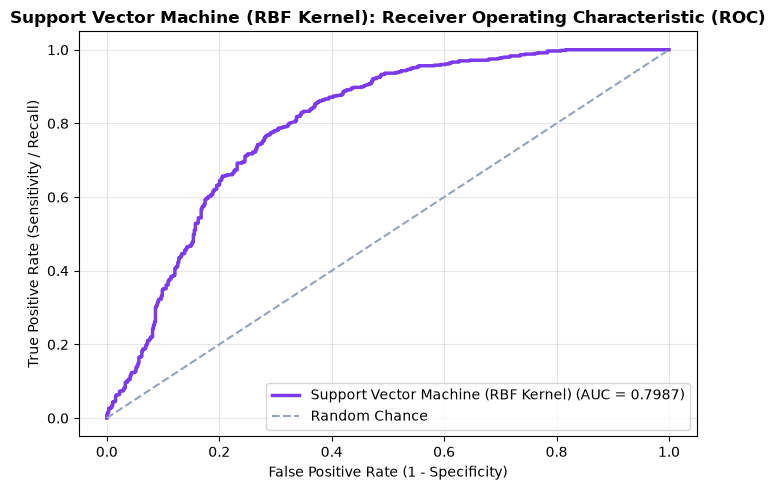

In [4]:
# 2. ROC Curve Plot
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#7C3AED', lw=2.5, label='Support Vector Machine (RBF Kernel) (AUC = ' + str(round(auc, 4)) + ')')
plt.plot([0, 1], [0, 1], color='#94A3B8', linestyle='--', label='Random Chance')
plt.title('Support Vector Machine (RBF Kernel): Receiver Operating Characteristic (ROC)', fontsize=12, fontweight='bold')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Support Vector Distribution
Summary of support vectors defining the maximum margin hyperplanes.

In [5]:
print(f'Total Support Vectors: {model.n_support_.sum():,}')
print(f'Support Vectors per Class (Active vs Churned): {model.n_support_}')

Total Support Vectors: 2,819
Support Vectors per Class (Active vs Churned): [1426 1393]
